In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Настройка отображения чисел
pd.options.display.float_format = "{:.4f}".format

In [ ]:

# 3.1. Загрузка данных

# Файл variant_2_data.csv должен находиться в той же директории
filename = "variant_2_data.csv"
df = pd.read_csv(filename)

print(" 3.1. Таблица исходных данных (фрагмент)")
print(df.head())  # Вывод первых строк
n = len(df)

 3.1. Таблица исходных данных (фрагмент)
   i      x       y
0  1 2.0318  1.1533
1  2 2.3529  1.2456
2  3 2.5446 -1.0206
3  4 3.0759  0.9780
4  5 3.3675 -0.3820


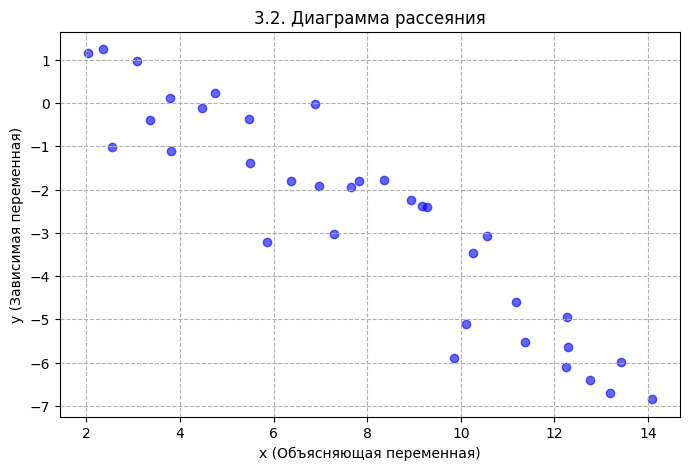

In [ ]:

# 3.2. Диаграмма рассеяния

plt.figure(figsize=(8, 5))
plt.scatter(df["x"], df["y"], color="blue", alpha=0.6)
plt.title("3.2. Диаграмма рассеяния")
plt.xlabel("x (Объясняющая переменная)")
plt.ylabel("y (Зависимая переменная)")
plt.grid(True, linestyle="--")
plt.show()
# Предварительный вывод: точки выстраиваются вдоль прямой с отрицательным наклоном.

In [ ]:

# 3.3. Оценивание коэффициентов регрессии

# 4.1. Средние значения
x_bar = df["x"].mean()
y_bar = df["y"].mean()

In [17]:
# 4.2. Вспомогательные суммы
Sxx = ((df["x"] - x_bar) ** 2).sum()
Sxy = ((df["x"] - x_bar) * (df["y"] - y_bar)).sum()

In [18]:
# 4.3. Оценки коэффициентов
beta1_hat = Sxy / Sxx  # Коэффициент наклона
beta0_hat = y_bar - beta1_hat * x_bar  # Свободный член

print(f"\n 3.3. Оценки коэффициентов:")
print(f"beta0_hat = {beta0_hat:.4f}")
print(f"beta1_hat = {beta1_hat:.4f}")
print(f"Уравнение регрессии: y_hat = {beta0_hat:.4f} + ({beta1_hat:.4f}) * x")  #


 3.3. Оценки коэффициентов:
beta0_hat = 2.4065
beta1_hat = -0.6366
Уравнение регрессии: y_hat = 2.4065 + (-0.6366) * x


In [ ]:

# 3.4. Расчёт прогнозных значений и остатков

df["y_hat"] = beta0_hat + beta1_hat * df["x"]  # Прогноз
df["e"] = df["y"] - df["y_hat"]  # Остаток
df["e2"] = df["e"] ** 2  # Квадрат остатка

print("\n 3.4. Расчетная таблица (фрагмент)")
print(df[["i", "x", "y", "y_hat", "e"]].head())


 3.4. Расчетная таблица (фрагмент)
   i      x       y  y_hat       e
0  1 2.0318  1.1533 1.1131  0.0402
1  2 2.3529  1.2456 0.9087  0.3369
2  3 2.5446 -1.0206 0.7867 -1.8073
3  4 3.0759  0.9780 0.4485  0.5295
4  5 3.3675 -0.3820 0.2629 -0.6449


In [ ]:

# 3.5. Оценка дисперсии ошибки

RSS = df["e2"].sum()  # Остаточная сумма квадратов
s2 = RSS / (n - 2)  # Несмещенная оценка дисперсии
s = np.sqrt(s2)  # Остаточное стандартное отклонение

print(f"\n 3.5. Оценки дисперсии:")
print(f"RSS = {RSS:.4f}")
print(f"s^2 = {s2:.4f}")
print(f"s = {s:.4f}")


 3.5. Оценки дисперсии:
RSS = 30.0737
s^2 = 0.9113
s = 0.9546


In [21]:
# 3.6. Доверительные интервалы для коэффициентов
alpha = 0.05
t_kp = stats.t.ppf(1 - alpha / 2, n - 2)  # Критическое значение Стьюдента

SE_beta1 = s / np.sqrt(Sxx)  # Стандартная ошибка beta1
SE_beta0 = s * np.sqrt(1 / n + (x_bar**2) / Sxx)  # Стандартная ошибка beta0

# Интервалы
ci_beta0 = (beta0_hat - t_kp * SE_beta0, beta0_hat + t_kp * SE_beta0)
ci_beta1 = (beta1_hat - t_kp * SE_beta1, beta1_hat + t_kp * SE_beta1)

print(f"\n 3.6. 95% Доверительные интервалы:")
print(f"ДИ для beta0: [{ci_beta0[0]:.4f}; {ci_beta0[1]:.4f}]")
print(f"ДИ для beta1: [{ci_beta1[0]:.4f}; {ci_beta1[1]:.4f}]")


 3.6. 95% Доверительные интервалы:
ДИ для beta0: [1.5979; 3.2151]
ДИ для beta1: [-0.7291; -0.5440]


In [22]:
# 3.7. Доверительный интервал для функции регрессии
# Подготовка данных для построения графика
x_range = np.linspace(df["x"].min(), df["x"].max(), 100)
y_range = beta0_hat + beta1_hat * x_range
SE_y_hat = s * np.sqrt(1 / n + (x_range - x_bar) ** 2 / Sxx)  #

lower_ci = y_range - t_kp * SE_y_hat
upper_ci = y_range + t_kp * SE_y_hat

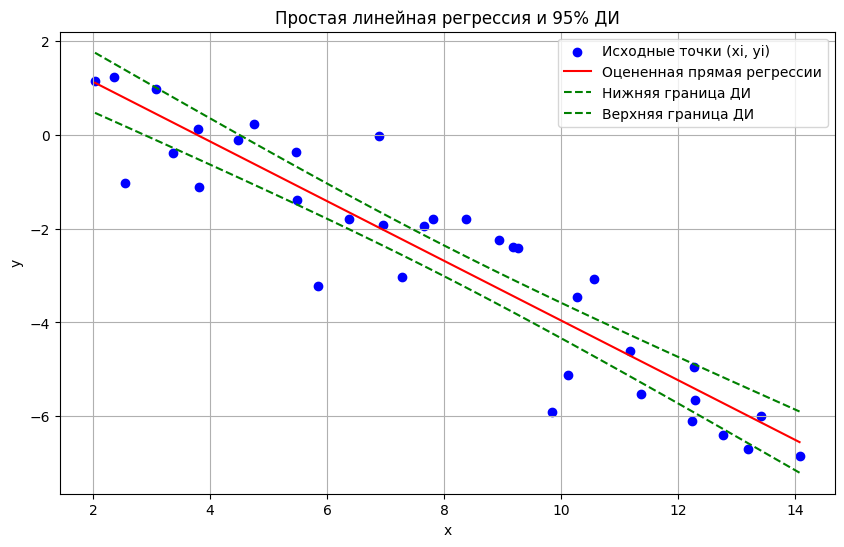

In [ ]:
# Итоговый график
plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], color='blue', label='Исходные точки (xi, yi)') #
plt.plot(x_range, y_range, color='red', label='Оцененная прямая регрессии') #
plt.plot(x_range, lower_ci, 'g--', label='Нижняя граница ДИ') #
plt.plot(x_range, upper_ci, 'g--', label='Верхняя граница ДИ') #

plt.title('Простая линейная регрессия и 95% ДИ')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()N

In [ ]:

# 4.10. Коэффициент детерминации

TSS = ((df["y"] - y_bar) ** 2).sum()  #
R2 = 1 - (RSS / TSS)  #
print(f"\nКоэффициент детерминации R^2 = {R2:.4f}")


Коэффициент детерминации R^2 = 0.8557
